# Inventory Quality Analysis

In [1]:
## Problem Statement
### To predict whether the uploaded product image in Inventory is defective or not.

In [2]:
# Importing Libraries

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
# ================================
# 3. Data Generators
# ================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    "train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_gen = test_datagen.flow_from_directory(
    "test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)


Found 6633 images belonging to 2 classes.
Found 715 images belonging to 2 classes.


In [4]:
# ================================
# 4. Model (CNN)
# ================================

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\hp\newenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape       ┃    Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ conv2d (Conv2D)           │ (None, 222, 222,   │        896 │
│                           │ 32)                │            │
├───────────────────────────┼────────────────────┼────────────┤
│ max_pooling2d             │ (None, 111, 111,   │          0 │
│ (MaxPooling2D)            │ 32)                │            │
├───────────────────────────┼────────────────────┼────────────┤
│ conv2d_1 (Conv2D)         │ (None, 109, 109,   │     18,496 │
│                           │ 64)                │            │
├───────────────────────────┼────────────────────┼────────────┤
│ max_pooling2d_1           │ (None, 54, 54, 64) │          0 │
│ (MaxPooling2D)            │                    │            │
├───────────────────────────┼────────────────────┼────────────┤
│ conv2d_2 (Conv2D)         │ (None, 52, 52,     │     73,856 │
│                           │ 128)               │            │
├───────────────────────────┼────────────────────┼────────────┤
│ max_pooling2d_2           │ (None, 26, 26,     │          0 │
│ (MaxPooling2D)            │ 128)               │            │
├───────────────────────────┼────────────────────┼────────────┤
│ flatten (Flatten)         │ (None, 86528)      │          0 │
├───────────────────────────┼────────────────────┼────────────┤
│ dense (Dense)             │ (None, 128)        │ 11,075,712 │
├───────────────────────────┼────────────────────┼────────────┤
│ dropout (Dropout)         │ (None, 128)        │          0 │
├───────────────────────────┼────────────────────┼────────────┤
│ dense_1 (Dense)           │ (None, 1)          │        129 │
└───────────────────────────┴────────────────────┴────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# ================================
# 5. Training
# ================================

history = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=10
)

Epoch 1/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 287s 1s/step - accuracy: 0.5928 - loss: 0.6911 - val_accuracy: 0.8014 - val_loss: 0.5237
Epoch 2/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 254s 1s/step - accuracy: 0.7980 - loss: 0.4426 - val_accuracy: 0.9385 - val_loss: 0.2230
Epoch 3/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 239s 1s/step - accuracy: 0.8737 - loss: 0.3228 - val_accuracy: 0.8084 - val_loss: 0.3965
Epoch 4/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 218s 1s/step - accuracy: 0.8943 - loss: 0.2783 - val_accuracy: 0.8280 - val_loss: 0.4038
Epoch 5/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 207s 993ms/step - accuracy: 0.9207 - loss: 0.2092 - val_accuracy: 0.9259 - val_loss: 0.1707
Epoch 6/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 231s 1s/step - accuracy: 0.9420 - loss: 0.1582 - val_accuracy: 0.8965 - val_loss: 0.2819
Epoch 7/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 280s 1s/step - accuracy: 0.9441 - loss: 0.1484 - val_accuracy: 0.8937 - val_loss: 0.2703
Epoch 8/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 309s 1s/step - accuracy: 0.9566 - loss: 0.1231 - val_a

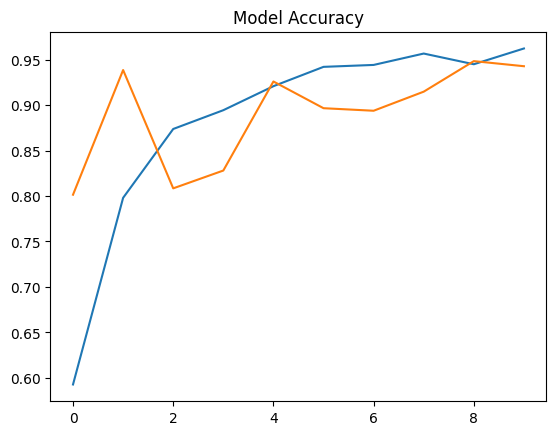

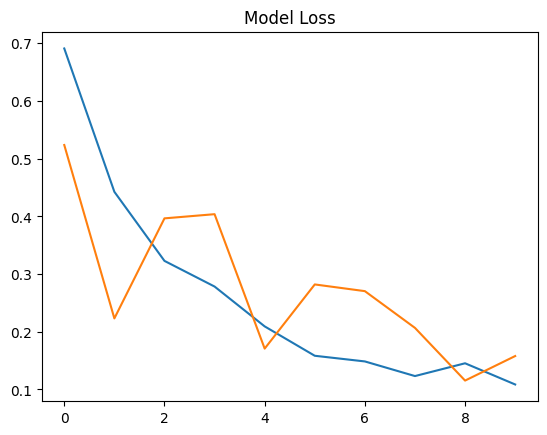

In [6]:
# ================================
# 6. Evaluation Visualization
# ================================

plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.show()

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.show()

In [7]:
# ================================
# 7. Save Model
# ================================

model.save("../models/Inventory_Quality_Analysis.h5")
print("Model saved successfully")

Model saved successfully


In [ ]:
# ================================
# 8. Prediction Function
# ================================

from tensorflow.keras.preprocessing import image

def predict_image(img_path, model_path="Inventory_Quality_Analysis.h5"):
    model = tf.keras.models.load_model(model_path)

    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)[0][0]

    if pred > 0.5:
        return "Non-Defective"
    else:
        return "Defective"